In [23]:
import numpy as np
import matplotlib.pyplot as plt

0.2886785935352141


<function matplotlib.pyplot.show(close=None, block=None)>

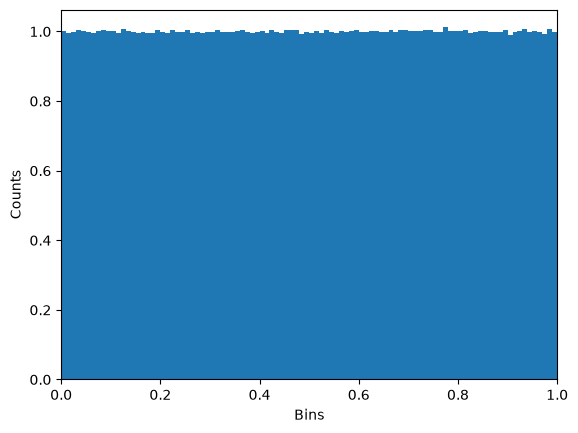

In [24]:
# Modelling Exercise 1a

rng = np.random.default_rng()

N = 10**7  # amount of random numbers
random_list = rng.random(N)

standard_deviation =np.std(random_list)

print(standard_deviation)
# print(random_list)
plt.hist(random_list,100, density=True)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.xlim(0,1)
plt.show

C:\Users\20203157\AppData\Local\Temp\ipykernel_34904\3174700267.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)


(0.0, 0.36203869407139994)

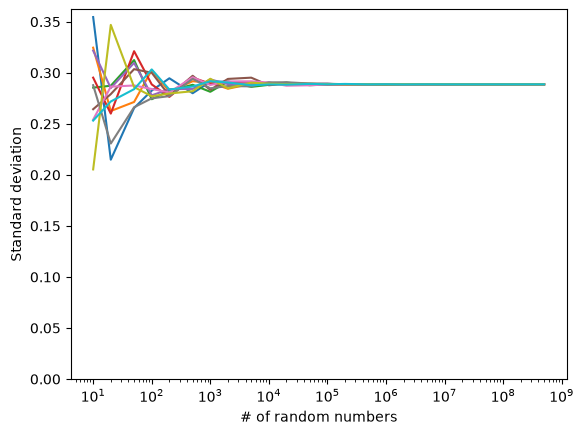

In [25]:
j=0
while j<10:
    N_range = [10, 2*10, 5*10, 10**2, 2*10**2, 5*10**2, 10**3, 2*10**3, 5*10**3, 10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 10**6, 2*10**6, 5*10**6, 10**7, 2*10**7, 5*10**7, 10**8, 2*10**8, 5*10**8]
    std_list = np.zeros(len(N_range))
    for i in range(len(N_range)):
        rng = np.random.default_rng()
        n = N_range[i]
        random_list = rng.random(n)
        std_list[i] = np.std(random_list)
        # print(f'Standard deviation of {n} random numbers is equal to {std_list[i]}.')

    stdplot = plt.semilogx(N_range, std_list)
    
    j+=1

plt.xlabel('# of random numbers')
plt.ylabel('Standard deviation')
plt.xlim(left=0)
plt.ylim(bottom=0)

In [26]:
# Modelling Exercise 1b

# Central limit theorem
N = 10**7
m = 20

rng = np.random.default_rng()

xi = np.zeros(N)

for _ in range(m):
    xi += np.sqrt(12/m)*(rng.random(N)-0.5)
    # Scaling with square root of 2, shifting by 3/m for m=6. 
    # By varying m, it is found that the shift should be fixed at 0.5.
    # By varying m, it is also found that the scaling should be sqrt(m/12)

mean = np.mean(xi)
std = np.std(xi)

print(f'standard deviation = {std:.3f}, mean = {mean:.3f}.')

set1 = xi

standard deviation = 1.000, mean = 0.000.


In [27]:
# Box-Muller method

set2 = np.zeros(N)
n_pairs = N//2

# Generating random pairs
xi1 = rng.random(n_pairs)
xi2 = rng.random(n_pairs)

# Calculating 'box-muller pairs'
xi_new1 = np.sqrt((-2*np.log(xi1)))*(np.cos(2*np.pi*xi2))
xi_new2 = np.sqrt((-2*np.log(xi1)))*(np.sin(2*np.pi*xi2))

# Determining the set by putting all 'Box-Muller pairs' in a row:
# Essentially alternating xi_new1 and xi_new2 values in an empty set
set2[0::2] = xi_new1
set2[1::2] = xi_new2

In [28]:
# Built-in normally distributed random number generator
N = 10**7
set3 = rng.standard_normal((N, 1)).flatten()

Central limit: RMSE = 1.292967e-03


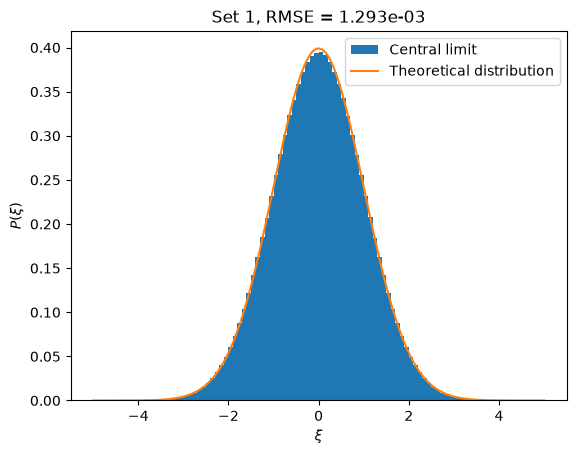

Box-Muller: RMSE = 3.369241e-04


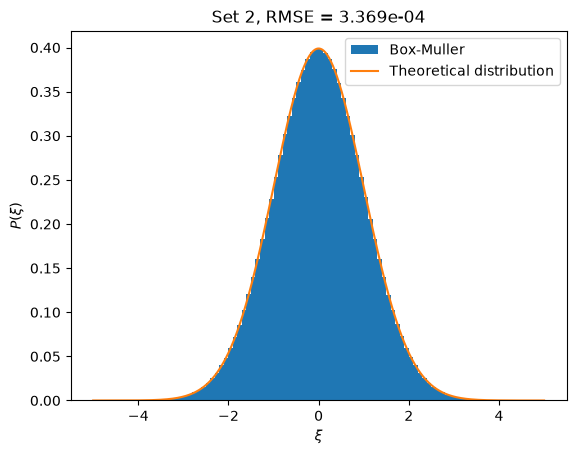

Numpy: RMSE = 3.328958e-04


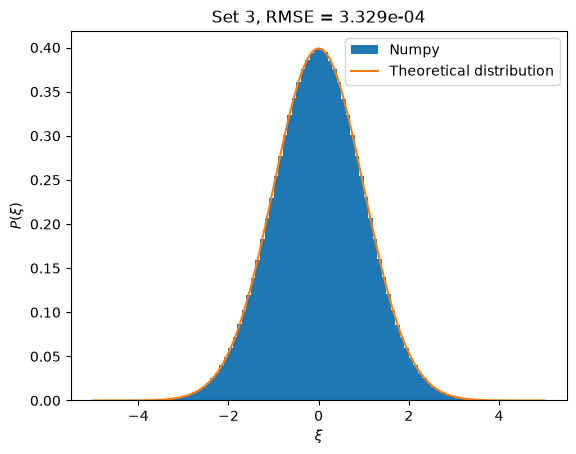

In [29]:
# Analysis of the three sets

sets = [set1, set2, set3]
labels = ['Central limit', 'Box-Muller', 'Numpy']
titles = ['Set 1', 'Set 2', 'Set 3']

x = np.linspace(-5, 5, 1000)
P = 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)

for data, label, title in zip(sets, labels, titles):
    plt.figure()

    # Histogram data used for RMSE
    hist, bin_edges = np.histogram(data,bins=100,range=(-5, 5),density=True)

    # Position of the centre of every histogram bin
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Theoretical Gaussian evaluated at those same positions
    P_analytical = (1/np.sqrt(2*np.pi)*np.exp(-bin_centers**2/2))

    # Root Mean Square Error
    rmse = np.sqrt(np.mean((hist - P_analytical)**2))

    print(f'{label}: RMSE = {rmse:.6e}')

    # Plot numerical distribution
    plt.hist(data,bins=100,range=(-5, 5),density=True,label=label)

    # Plot theoretical distribution
    plt.plot(x,P,label="Theoretical distribution")

    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$P(\xi)$")
    plt.legend()
    plt.title(f'{title}, RMSE = {rmse:.3e}')

    plt.show()

L =     1: <R²> = 40.00, error = nan


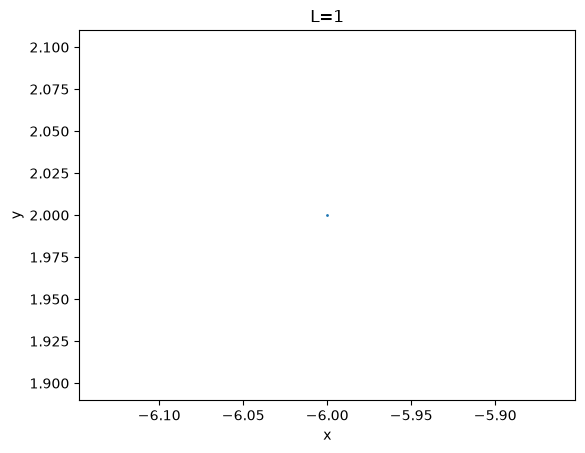

L =    10: <R²> = 72.20, error = 32.32


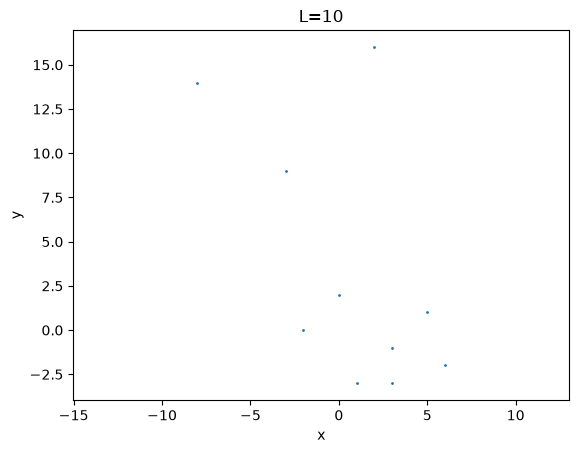

L =   100: <R²> = 100.82, error = 8.92


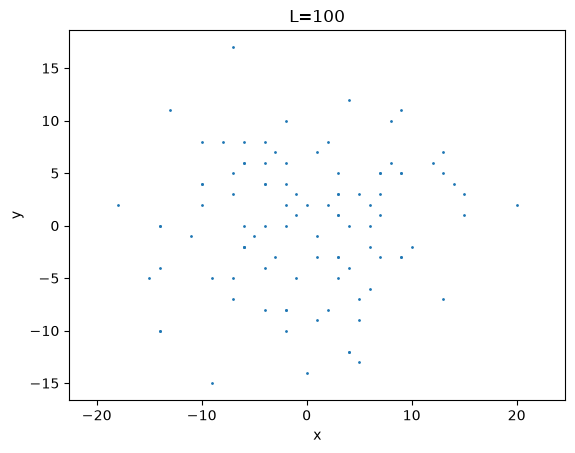

L =  1000: <R²> = 102.10, error = 3.27


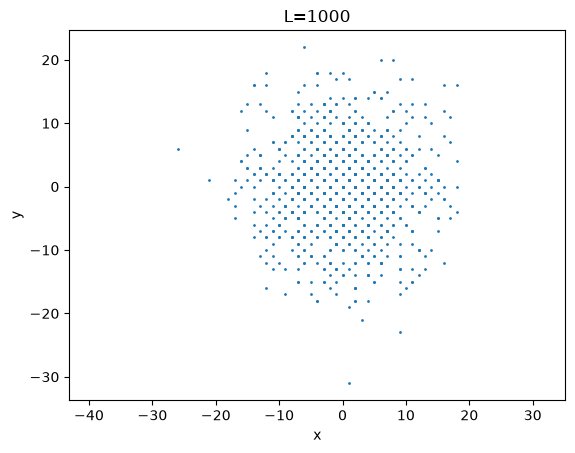

L = 10000: <R²> = 100.12, error = 0.99


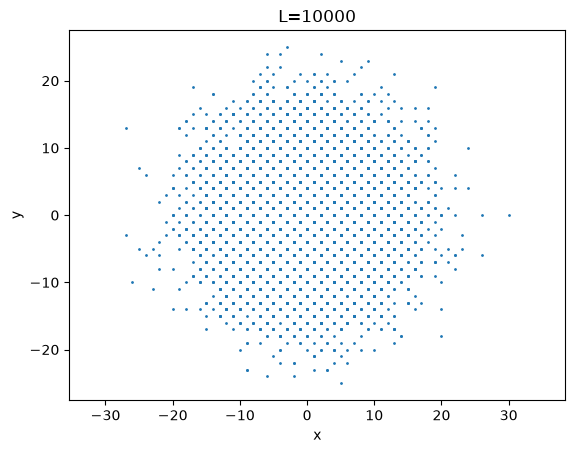

In [38]:
# Modelling Exercise 1c

rng = np.random.default_rng()

L_values = [1, 10, 100, 1000, 10000]
titles = ['L=1', 'L=10', 'L=100', 'L=1000', 'L=10000']


N = 100 # number of steps in a random walk
r = 1   # length of a step
mean_R_squared_values = np.zeros(len(L_values))
error_values = np.zeros(len(L_values))

for i in range(len(L_values)):
    title = titles[i]
    L = L_values[i]
    x, y = (0,0)
    X, Y = (np.zeros(L), np.zeros(L))
    for walk in range(L):
        steps = rng.integers(0,4, size=(N))
        steps_pos_x = sum(steps==0)
        steps_neg_x = sum(steps==1)
        steps_pos_y = sum(steps==2)
        steps_neg_y = sum(steps==3)

        X[walk] = x + r*(steps_pos_x - steps_neg_x)
        Y[walk] = y + r*(steps_pos_y - steps_neg_y)


    # End-to-end squared distances
    R_squared = X**2 + Y**2

    # Mean squared end-to-end distance
    mean_R_squared = np.mean(R_squared)
    mean_R_squared_values[i] = (mean_R_squared)

    # Standard error of the mean
    error = np.std(R_squared, ddof=1) / np.sqrt(L)

    error_values[i] = (error)

    print(f"L = {L:5d}: <R²> = {mean_R_squared:.2f}, error = {error:.2f}")

    plt.scatter(X, Y, s=1)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)
    plt.show()


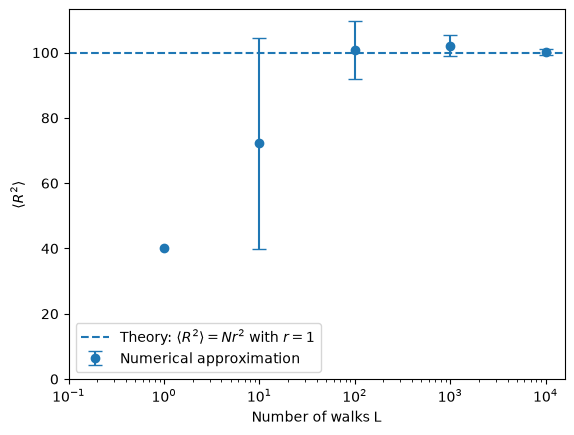

In [39]:
theoretical_R_squared = N*r**2

plt.errorbar(
    L_values,
    mean_R_squared_values,
    yerr=error_values,
    fmt="o",
    capsize=5,
    label="Numerical approximation")

plt.axhline(
    theoretical_R_squared,
    linestyle="--",
    label=r"Theory: $\langle R^2\rangle = Nr^2$ with $r=1$",
)

plt.xscale("log")
plt.xlabel("Number of walks L")
plt.ylabel(r"$\langle R^2\rangle$")
plt.legend()
plt.xlim(left=.1)
plt.ylim(bottom=0)
plt.show()